# 🚗 NCR Ride Bookings — Multi-Target ML Modeling Notebook
### Targets
| # | Target | Task |
|---|--------|------|
| 1 | `Booking Status` | Binary Classification (Completed vs Cancelled) |
| 2 | `Driver Ratings` | Regression (1–5 stars) |
| 3 | `Customer Rating` | Regression (1–5 stars) |


In [1]:
# ── 1. Imports & Configuration ────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)
from xgboost import XGBClassifier, XGBRegressor
import joblib
import os

# ── Plotting style ─────────────────────────────────────────────────────────
DARK_BG   = "#1a1a2e"
ACCENT    = "#16213e"
HIGHLIGHT = "#e94560"
PALETTE   = ["#e94560", "#0f3460", "#16213e", "#533483", "#2d6a4f",
             "#f4a261", "#264653"]

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor":   ACCENT,
    "axes.edgecolor":   "#ffffff30",
    "axes.labelcolor":  "white",
    "xtick.color":      "white",
    "ytick.color":      "white",
    "text.color":       "white",
    "grid.color":       "#ffffff15",
    "figure.figsize":   (14, 5),
})

MODELS_DIR = "saved_models"
os.makedirs(MODELS_DIR, exist_ok=True)
print("✅ Libraries loaded | models directory ready →", MODELS_DIR)


✅ Libraries loaded | models directory ready → saved_models


In [ ]:
# ── Version Pin: record sklearn + xgboost versions used to train ──────────
# IMPORTANT: The Streamlit app must use the SAME sklearn version as this
# notebook. Run this cell first and note the printed versions.
import sklearn, xgboost, joblib, platform

print('=' * 55)
print('  Environment Snapshot (required for app.py compatibility)')
print('=' * 55)
print(f'  Python       : {platform.python_version()}')
print(f'  scikit-learn : {sklearn.__version__}')
print(f'  xgboost      : {xgboost.__version__}')
print(f'  joblib       : {joblib.__version__}')
print('=' * 55)
print()
print('To match this in your Streamlit environment, run:')
print(f'  pip install scikit-learn=={sklearn.__version__} ')
print(f'              xgboost=={xgboost.__version__}')

# Save a small version manifest alongside the models so app.py can read it
import json as _json, os as _os
_os.makedirs(MODELS_DIR, exist_ok=True)
with open(f'{MODELS_DIR}/version_manifest.json', 'w') as _f:
    _json.dump({
        'python':       platform.python_version(),
        'sklearn':      sklearn.__version__,
        'xgboost':      xgboost.__version__,
        'joblib':       joblib.__version__,
    }, _f, indent=2)
print()
print('version_manifest.json written to', MODELS_DIR)

  Environment Snapshot (required for app.py compatibility)
  Python       : 3.13.5
  scikit-learn : 1.7.1
  xgboost      : 3.1.2
  joblib       : 1.4.2

To match this in your Streamlit environment, run:
  pip install scikit-learn==1.7.1 
              xgboost==3.1.2

version_manifest.json written to saved_models


In [3]:
# ── 2. Load Dataset ────────────────────────────────────────────────────────
df_raw = pd.read_csv("ncr_ride_bookings.csv")

print(f"Dataset shape  : {df_raw.shape}")
print(f"Memory usage   : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print("\nColumn overview:")
print(df_raw.dtypes.to_frame("dtype").join(
      df_raw.isnull().sum().to_frame("nulls")))

Dataset shape  : (150000, 21)
Memory usage   : 105.6 MB

Column overview:
                                     dtype   nulls
Date                                object       0
Time                                object       0
Booking ID                          object       0
Booking Status                      object       0
Customer ID                         object       0
Vehicle Type                        object       0
Pickup Location                     object       0
Drop Location                       object       0
Avg VTAT                           float64   10500
Avg CTAT                           float64   48000
Cancelled Rides by Customer        float64  139500
Reason for cancelling by Customer   object  139500
Cancelled Rides by Driver          float64  123000
Driver Cancellation Reason          object  123000
Incomplete Rides                   float64  141000
Incomplete Rides Reason             object  141000
Booking Value                      float64   48000
Ride Dis

## 📊 Section 1 — Target Column Analysis

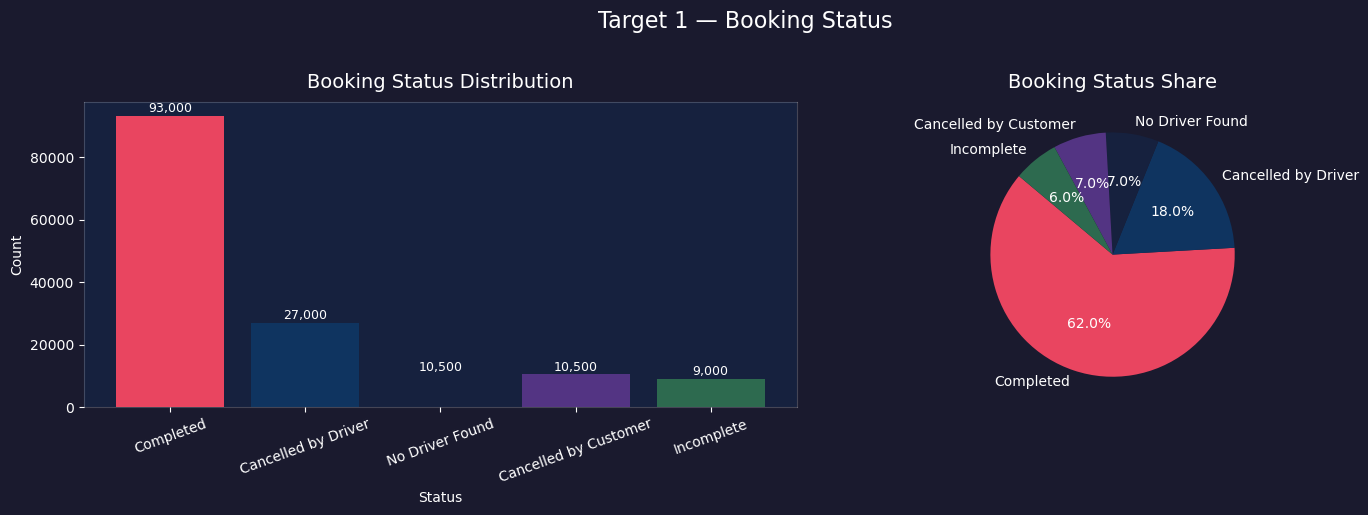


Value Counts:
 Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


In [4]:
# ── 3. Booking Status Distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

status_counts = df_raw['Booking Status'].value_counts()
axes[0].bar(status_counts.index, status_counts.values,
            color=PALETTE[:len(status_counts)])
axes[0].set_title("Booking Status Distribution", fontsize=14, pad=10)
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f"{val:,}", ha='center', va='bottom', fontsize=9)
axes[0].tick_params(axis='x', rotation=20)

# Pie chart
axes[1].pie(status_counts.values, labels=status_counts.index,
            colors=PALETTE[:len(status_counts)], autopct='%1.1f%%',
            startangle=140, textprops={'color': 'white'})
axes[1].set_title("Booking Status Share", fontsize=14, pad=10)

plt.suptitle("Target 1 — Booking Status", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
print("\nValue Counts:\n", status_counts)

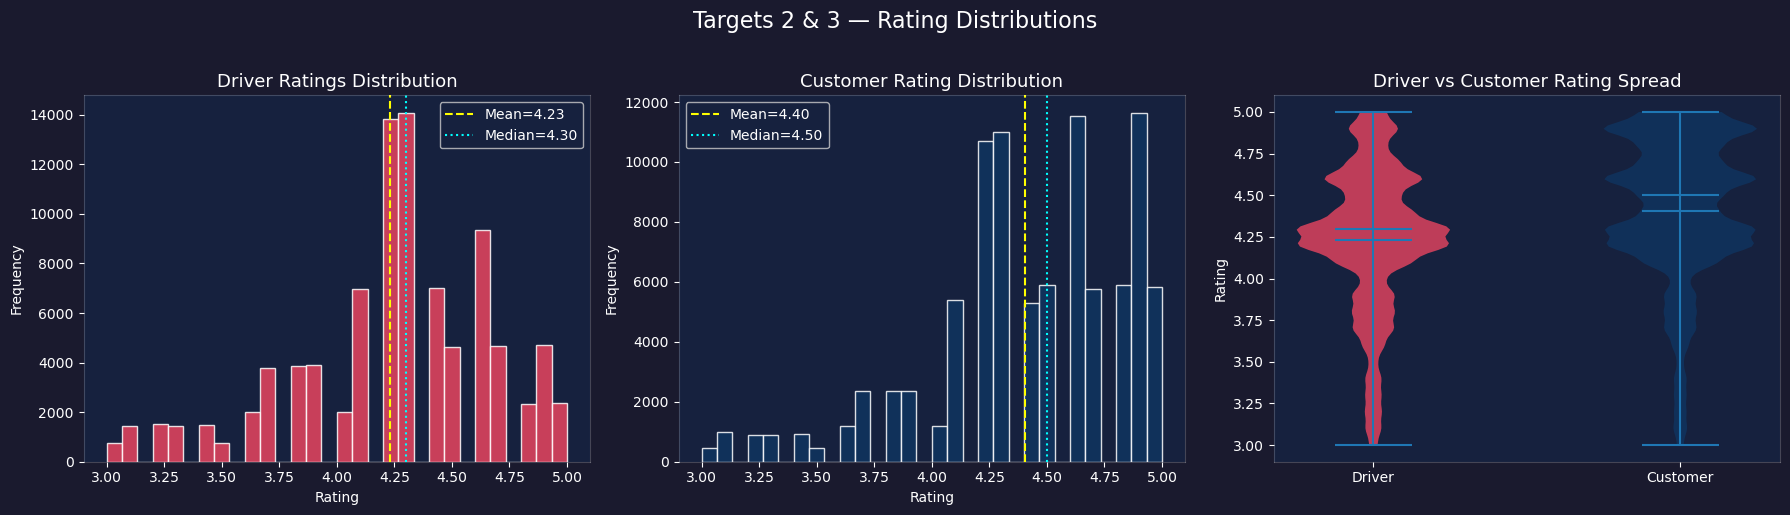

Driver Ratings   — Mean: 4.231 | Std: 0.437 | Skew: -0.656
Customer Rating  — Mean: 4.405 | Std: 0.438 | Skew: -0.886


In [5]:
# ── 4. Rating Distributions ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Driver Ratings
dr = df_raw['Driver Ratings'].dropna()
axes[0].hist(dr, bins=30, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].axvline(dr.mean(), color='yellow', linestyle='--', label=f'Mean={dr.mean():.2f}')
axes[0].axvline(dr.median(), color='cyan', linestyle=':', label=f'Median={dr.median():.2f}')
axes[0].set_title("Driver Ratings Distribution", fontsize=13)
axes[0].set_xlabel("Rating"); axes[0].set_ylabel("Frequency")
axes[0].legend()

# Customer Rating
cr = df_raw['Customer Rating'].dropna()
axes[1].hist(cr, bins=30, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[1].axvline(cr.mean(), color='yellow', linestyle='--', label=f'Mean={cr.mean():.2f}')
axes[1].axvline(cr.median(), color='cyan', linestyle=':', label=f'Median={cr.median():.2f}')
axes[1].set_title("Customer Rating Distribution", fontsize=13)
axes[1].set_xlabel("Rating"); axes[1].set_ylabel("Frequency")
axes[1].legend()

# Side-by-side violin
data_plot = pd.DataFrame({
    'Rating': pd.concat([dr.rename('v'), cr.rename('v')]),
    'Type':   ['Driver']*len(dr) + ['Customer']*len(cr)
})
vp = axes[2].violinplot(
    [dr.values, cr.values], positions=[1, 2],
    showmeans=True, showmedians=True
)
for pc, col in zip(vp['bodies'], [PALETTE[0], PALETTE[1]]):
    pc.set_facecolor(col); pc.set_alpha(0.8)
axes[2].set_xticks([1, 2]); axes[2].set_xticklabels(['Driver', 'Customer'])
axes[2].set_title("Driver vs Customer Rating Spread", fontsize=13)
axes[2].set_ylabel("Rating")

plt.suptitle("Targets 2 & 3 — Rating Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f"Driver Ratings   — Mean: {dr.mean():.3f} | Std: {dr.std():.3f} | Skew: {dr.skew():.3f}")
print(f"Customer Rating  — Mean: {cr.mean():.3f} | Std: {cr.std():.3f} | Skew: {cr.skew():.3f}")

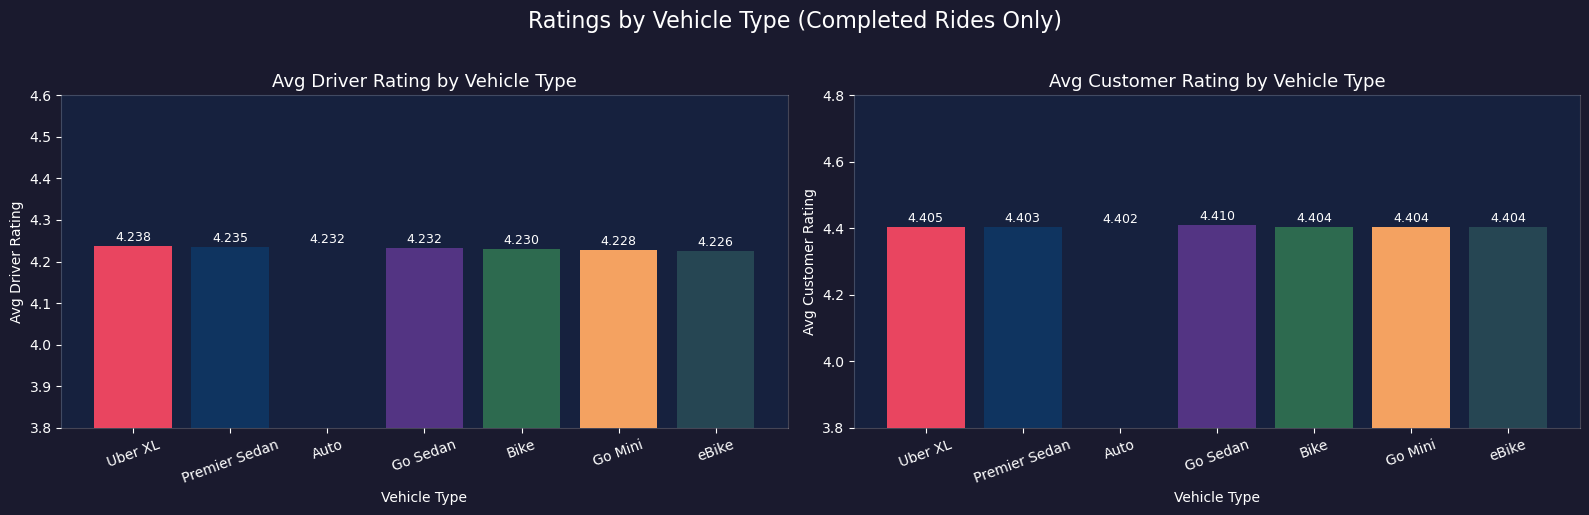

In [6]:
# ── 5. Ratings by Vehicle Type ─────────────────────────────────────────────
completed = df_raw[df_raw['Booking Status'] == 'Completed'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
vt_order = completed.groupby('Vehicle Type')['Driver Ratings'].mean().sort_values(ascending=False).index

# Driver Ratings by Vehicle Type
dr_vt = completed.groupby('Vehicle Type')['Driver Ratings'].mean().reindex(vt_order)
bars = axes[0].bar(dr_vt.index, dr_vt.values, color=PALETTE[:len(dr_vt)])
axes[0].set_ylim(3.8, 4.6)
axes[0].set_title("Avg Driver Rating by Vehicle Type", fontsize=13)
axes[0].set_xlabel("Vehicle Type"); axes[0].set_ylabel("Avg Driver Rating")
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, dr_vt.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=9)

# Customer Rating by Vehicle Type
cr_vt = completed.groupby('Vehicle Type')['Customer Rating'].mean().reindex(vt_order)
bars2 = axes[1].bar(cr_vt.index, cr_vt.values, color=PALETTE[:len(cr_vt)])
axes[1].set_ylim(3.8, 4.8)
axes[1].set_title("Avg Customer Rating by Vehicle Type", fontsize=13)
axes[1].set_xlabel("Vehicle Type"); axes[1].set_ylabel("Avg Customer Rating")
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars2, cr_vt.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=9)

plt.suptitle("Ratings by Vehicle Type (Completed Rides Only)", fontsize=16, y=1.02)
plt.tight_layout(); plt.show()


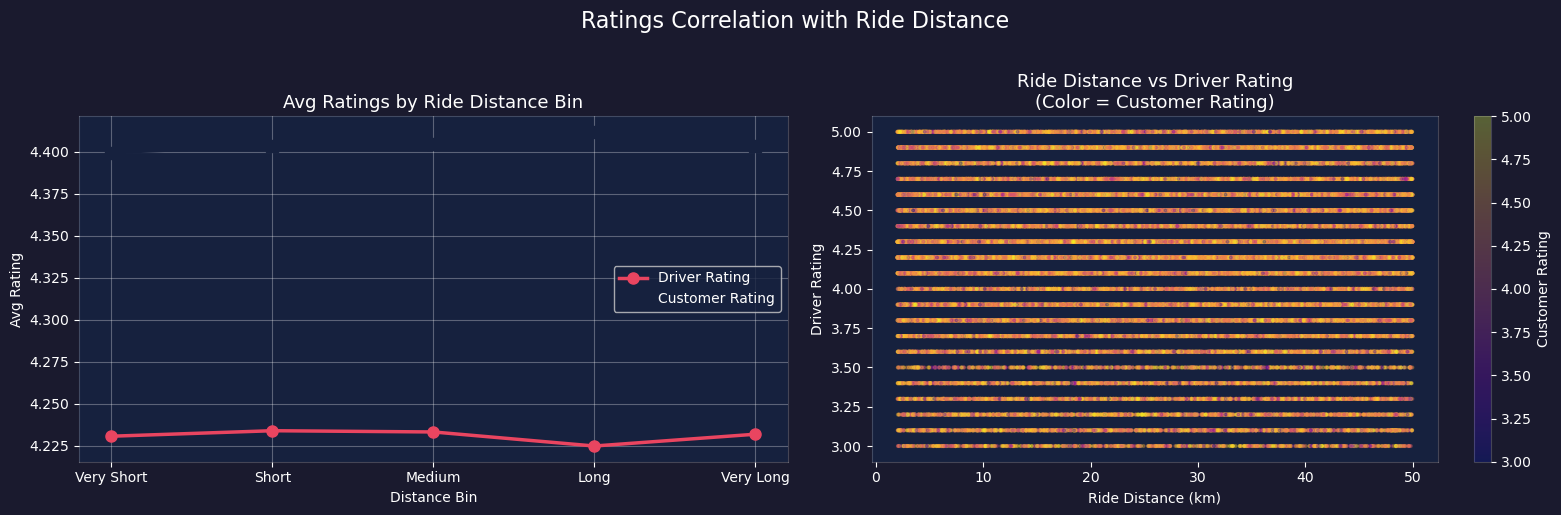


Correlation Matrix (Completed Rides):
                 Ride Distance  Avg VTAT  Avg CTAT  Driver Ratings  \
Ride Distance            1.000     0.004     0.001          -0.002   
Avg VTAT                 0.004     1.000     0.002          -0.005   
Avg CTAT                 0.001     0.002     1.000           0.001   
Driver Ratings          -0.002    -0.005     0.001           1.000   
Customer Rating          0.005    -0.004     0.001          -0.001   

                 Customer Rating  
Ride Distance              0.005  
Avg VTAT                  -0.004  
Avg CTAT                   0.001  
Driver Ratings            -0.001  
Customer Rating            1.000  


In [7]:
# ── 6. Ratings vs Ride Distance ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bin ride distance into quartiles for cleaner visualization
completed['Distance_Bin'] = pd.qcut(completed['Ride Distance'],
                                    q=5, labels=['Very Short','Short','Medium','Long','Very Long'])

dr_dist = completed.groupby('Distance_Bin', observed=True)['Driver Ratings'].mean()
cr_dist = completed.groupby('Distance_Bin', observed=True)['Customer Rating'].mean()

axes[0].plot(dr_dist.index, dr_dist.values, marker='o', color=PALETTE[0],
             linewidth=2.5, markersize=8, label='Driver Rating')
axes[0].plot(cr_dist.index, cr_dist.values, marker='s', color=PALETTE[2],
             linewidth=2.5, markersize=8, label='Customer Rating')
axes[0].set_title("Avg Ratings by Ride Distance Bin", fontsize=13)
axes[0].set_xlabel("Distance Bin"); axes[0].set_ylabel("Avg Rating")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Scatter: Ride Distance vs Driver Rating with density
scatter = axes[1].scatter(completed['Ride Distance'], completed['Driver Ratings'],
                          c=completed['Customer Rating'], cmap='plasma',
                          alpha=0.3, s=4, rasterized=True)
plt.colorbar(scatter, ax=axes[1], label='Customer Rating')
axes[1].set_title("Ride Distance vs Driver Rating\n(Color = Customer Rating)", fontsize=13)
axes[1].set_xlabel("Ride Distance (km)"); axes[1].set_ylabel("Driver Rating")

plt.suptitle("Ratings Correlation with Ride Distance", fontsize=16, y=1.02)
plt.tight_layout(); plt.show()

print("\nCorrelation Matrix (Completed Rides):")
print(completed[['Ride Distance','Avg VTAT','Avg CTAT','Driver Ratings','Customer Rating']].corr().round(3))


## 🔧 Section 2 — Data Preprocessing & Feature Engineering

In [8]:
# ── 7. Binary Target for Cancellation Classification ─────────────────────
# Strategy: Completed = 0, everything else = 1 (any non-completion is a risk)
# For cleaner signal, we focus on Completed vs Cancelled (drop Incomplete/NoDriver)
df = df_raw.copy()

# Create binary cancellation label
#   0 = Completed | 1 = Cancelled (by driver or customer)
df['is_cancelled'] = df['Booking Status'].apply(
    lambda x: 0 if x == 'Completed' else 1
)

print("Binary Target Distribution:")
print(df['is_cancelled'].value_counts())
print(f"\nCancellation Rate: {df['is_cancelled'].mean()*100:.1f}%")

Binary Target Distribution:
is_cancelled
0    93000
1    57000
Name: count, dtype: int64

Cancellation Rate: 38.0%


In [9]:
# ── 8. Feature Engineering — Temporal Features ───────────────────────────
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce')

df['Hour']      = df['Time'].dt.hour
df['DayOfWeek'] = df['Date'].dt.dayofweek        # 0=Monday … 6=Sunday
df['Month']     = df['Date'].dt.month
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

# Rush-hour flag (7-10 AM and 5-8 PM)
df['IsRushHour'] = df['Hour'].apply(
    lambda h: 1 if (7 <= h <= 10) or (17 <= h <= 20) else 0
)

print("Engineered temporal features:")
print(df[['Hour','DayOfWeek','Month','IsWeekend','IsRushHour']].describe())

Engineered temporal features:
                Hour      DayOfWeek          Month      IsWeekend  \
count  150000.000000  150000.000000  150000.000000  150000.000000   
mean       14.034113       2.996987       6.490940       0.286267   
std         5.416906       2.003202       3.444028       0.452017   
min         0.000000       0.000000       1.000000       0.000000   
25%        10.000000       1.000000       3.000000       0.000000   
50%        15.000000       3.000000       7.000000       0.000000   
75%        18.000000       5.000000       9.000000       1.000000   
max        23.000000       6.000000      12.000000       1.000000   

          IsRushHour  
count  150000.000000  
mean        0.494933  
std         0.499976  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         1.000000  
max         1.000000  


In [10]:
# ── 9. Define Feature Set ─────────────────────────────────────────────────
NUMERICAL_FEATURES = ['Avg VTAT', 'Avg CTAT', 'Ride Distance', 'Booking Value',
                      'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'IsRushHour']

CATEGORICAL_OHE    = ['Vehicle Type']           # One-Hot Encoding
CATEGORICAL_LE     = ['Pickup Location', 'Drop Location']  # Label Encoding

ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_OHE + CATEGORICAL_LE

print(f"Total Features  : {len(ALL_FEATURES)}")
print(f"Numerical       : {NUMERICAL_FEATURES}")
print(f"OHE Categorical : {CATEGORICAL_OHE}")
print(f"LE Categorical  : {CATEGORICAL_LE}")

Total Features  : 12
Numerical       : ['Avg VTAT', 'Avg CTAT', 'Ride Distance', 'Booking Value', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'IsRushHour']
OHE Categorical : ['Vehicle Type']
LE Categorical  : ['Pickup Location', 'Drop Location']


In [11]:
# ── 10. Label Encoding for Location Columns ──────────────────────────────
le_pickup = LabelEncoder()
le_drop   = LabelEncoder()

# Fit on full dataset to capture all categories
df['Pickup_Enc'] = le_pickup.fit_transform(df['Pickup Location'])
df['Drop_Enc']   = le_drop.fit_transform(df['Drop Location'])

# Update feature lists with encoded columns
NUMERICAL_FEATURES_ENC = NUMERICAL_FEATURES + ['Pickup_Enc', 'Drop_Enc']

# Save label encoders
joblib.dump(le_pickup, f"{MODELS_DIR}/le_pickup.pkl")
joblib.dump(le_drop,   f"{MODELS_DIR}/le_drop.pkl")
print(f"✅ Label encoders saved | Pickup classes: {len(le_pickup.classes_)} | Drop classes: {len(le_drop.classes_)}")

✅ Label encoders saved | Pickup classes: 176 | Drop classes: 176


In [12]:
# ── 11. Build Preprocessing Pipelines ────────────────────────────────────
# Numerical imputer (median)
num_imputer = SimpleImputer(strategy='median')

# OHE for Vehicle Type
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# ColumnTransformer combines both transformations
preprocessor = ColumnTransformer(transformers=[
    ('num', num_imputer,  NUMERICAL_FEATURES_ENC),
    ('ohe', ohe,          CATEGORICAL_OHE),
], remainder='drop')

print("Preprocessor built:")
print(preprocessor)

Preprocessor built:
ColumnTransformer(transformers=[('num', SimpleImputer(strategy='median'),
                                 ['Avg VTAT', 'Avg CTAT', 'Ride Distance',
                                  'Booking Value', 'Hour', 'DayOfWeek', 'Month',
                                  'IsWeekend', 'IsRushHour', 'Pickup_Enc',
                                  'Drop_Enc']),
                                ('ohe',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Vehicle Type'])])


## 🎯 Section 3 — Model 1: Ride Cancellation Classifier

In [13]:
# ── 12. Prepare Classification Dataset ──────────────────────────────────
clf_features = NUMERICAL_FEATURES_ENC + CATEGORICAL_OHE
clf_df       = df[clf_features + ['is_cancelled']].copy()

# For cancelled rides, Ride Distance / Booking Value / CTAT are NaN — keep them,
# the imputer will handle via median fill.
X_clf = clf_df[clf_features]
y_clf = clf_df['is_cancelled']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Training set : {X_train_c.shape} | Test set: {X_test_c.shape}")
print(f"Class balance — Train : {y_train_c.value_counts(normalize=True).round(3).to_dict()}")

Training set : (120000, 12) | Test set: (30000, 12)
Class balance — Train : {0: 0.62, 1: 0.38}


In [14]:
# ── 13. Random Forest Classifier ─────────────────────────────────────────
rf_clf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

rf_clf_pipeline.fit(X_train_c, y_train_c)
y_pred_rf_c  = rf_clf_pipeline.predict(X_test_c)
y_proba_rf_c = rf_clf_pipeline.predict_proba(X_test_c)[:, 1]

print("=" * 60)
print("  RANDOM FOREST CLASSIFIER — Results")
print("=" * 60)
print(classification_report(y_test_c, y_pred_rf_c,
      target_names=['Completed (0)', 'Cancelled (1)']))


  RANDOM FOREST CLASSIFIER — Results
               precision    recall  f1-score   support

Completed (0)       0.94      0.98      0.96     18600
Cancelled (1)       0.97      0.90      0.93     11400

     accuracy                           0.95     30000
    macro avg       0.96      0.94      0.95     30000
 weighted avg       0.95      0.95      0.95     30000



In [ ]:
# ── 14. XGBoost Classifier ───────────────────────────────────────────────
# Preprocess training data first for XGBoost
X_train_c_proc = preprocessor.fit_transform(X_train_c)
X_test_c_proc  = preprocessor.transform(X_test_c)

scale_pos_weight = (y_train_c == 0).sum() / (y_train_c == 1).sum()

xgb_clf = XGBClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_clf.fit(X_train_c_proc, y_train_c)
y_pred_xgb_c  = xgb_clf.predict(X_test_c_proc)
y_proba_xgb_c = xgb_clf.predict_proba(X_test_c_proc)[:, 1]

print("=" * 60)
print("  XGBOOST CLASSIFIER — Results")
print("=" * 60)
print(classification_report(y_test_c, y_pred_xgb_c,
      target_names=['Completed (0)', 'Cancelled (1)']))

  XGBOOST CLASSIFIER — Results
               precision    recall  f1-score   support

Completed (0)       0.96      0.96      0.96     18600
Cancelled (1)       0.93      0.93      0.93     11400

     accuracy                           0.94     30000
    macro avg       0.94      0.94      0.94     30000
 weighted avg       0.94      0.94      0.94     30000



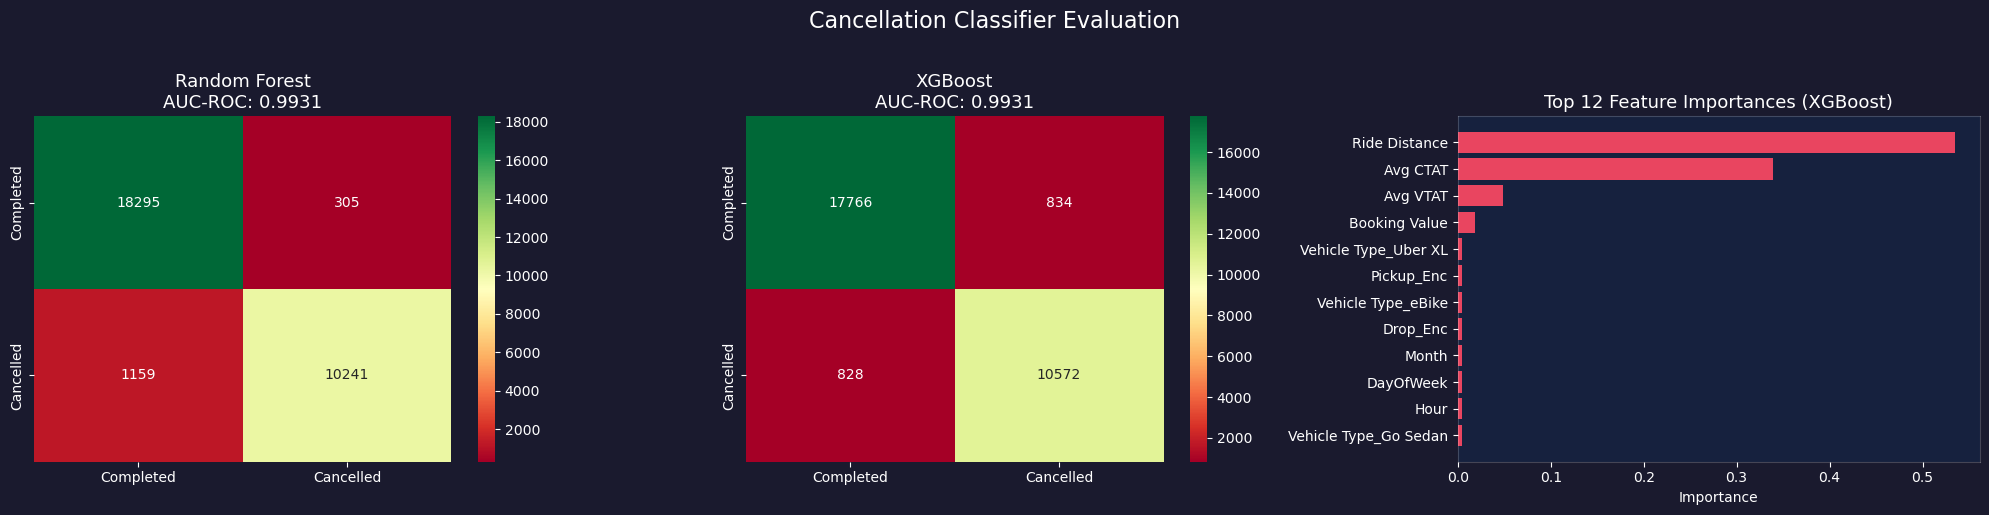


Model                AUC-ROC   
------------------------------
Random Forest        0.9931
XGBoost              0.9931


In [16]:
# ── 15. Classifier Comparison & Confusion Matrices ───────────────────────
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Confusion Matrix — RF
cm_rf = confusion_matrix(y_test_c, y_pred_rf_c)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Completed','Cancelled'],
            yticklabels=['Completed','Cancelled'], ax=axes[0])
axes[0].set_title(f"Random Forest\nAUC-ROC: {roc_auc_score(y_test_c, y_proba_rf_c):.4f}", fontsize=13)

# Confusion Matrix — XGB
cm_xgb = confusion_matrix(y_test_c, y_pred_xgb_c)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Completed','Cancelled'],
            yticklabels=['Completed','Cancelled'], ax=axes[1])
axes[1].set_title(f"XGBoost\nAUC-ROC: {roc_auc_score(y_test_c, y_proba_xgb_c):.4f}", fontsize=13)

# Feature Importances (XGBoost)
feature_names_enc = (
    preprocessor.named_transformers_['num'].get_feature_names_out(NUMERICAL_FEATURES_ENC).tolist()
    if hasattr(preprocessor.named_transformers_['num'], 'get_feature_names_out')
    else NUMERICAL_FEATURES_ENC
)
ohe_features = preprocessor.named_transformers_['ohe'].get_feature_names_out(CATEGORICAL_OHE).tolist()
all_enc_features = NUMERICAL_FEATURES_ENC + ohe_features

importances = xgb_clf.feature_importances_
feat_imp = pd.Series(importances, index=all_enc_features[:len(importances)]).nlargest(12)
axes[2].barh(feat_imp.index[::-1], feat_imp.values[::-1], color=PALETTE[0])
axes[2].set_title("Top 12 Feature Importances (XGBoost)", fontsize=13)
axes[2].set_xlabel("Importance")

plt.suptitle("Cancellation Classifier Evaluation", fontsize=16, y=1.02)
plt.tight_layout(); plt.show()

print(f"\n{'Model':<20} {'AUC-ROC':<10}")
print("-" * 30)
print(f"{'Random Forest':<20} {roc_auc_score(y_test_c, y_proba_rf_c):.4f}")
print(f"{'XGBoost':<20} {roc_auc_score(y_test_c, y_proba_xgb_c):.4f}")


In [17]:
# ── 16. Save Best Classification Model ───────────────────────────────────
# Save both the fitted preprocessor and the XGBoost model
joblib.dump(preprocessor,   f"{MODELS_DIR}/preprocessor.pkl")
joblib.dump(xgb_clf,        f"{MODELS_DIR}/xgb_cancellation_model.pkl")
joblib.dump(rf_clf_pipeline,f"{MODELS_DIR}/rf_cancellation_pipeline.pkl")
print("✅ Cancellation models saved successfully")


✅ Cancellation models saved successfully


## ⭐ Section 4 — Model 2: Driver Rating Regressor

In [18]:
# ── 17. Prepare Driver Rating Dataset ────────────────────────────────────
# Ratings only exist for completed rides — filter accordingly
reg_df = df[df['Booking Status'] == 'Completed'].copy()
print(f"Completed rides for regression: {len(reg_df):,}")

reg_features = NUMERICAL_FEATURES_ENC + CATEGORICAL_OHE

# Driver Rating Target
X_dr = reg_df[reg_features]
y_dr = reg_df['Driver Ratings']

# Drop rows where target is NaN
mask_dr  = y_dr.notna()
X_dr, y_dr = X_dr[mask_dr], y_dr[mask_dr]

X_train_dr, X_test_dr, y_train_dr, y_test_dr = train_test_split(
    X_dr, y_dr, test_size=0.2, random_state=42
)
print(f"Driver Rating dataset  — Train: {X_train_dr.shape} | Test: {X_test_dr.shape}")


Completed rides for regression: 93,000
Driver Rating dataset  — Train: (74400, 12) | Test: (18600, 12)


In [19]:
# ── 18. Build a Fresh Preprocessor for Regression ────────────────────────
# (Need a separate instance so fit is not contaminated by clf data)
num_imp_reg = SimpleImputer(strategy='median')
ohe_reg     = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor_reg = ColumnTransformer(transformers=[
    ('num', num_imp_reg, NUMERICAL_FEATURES_ENC),
    ('ohe', ohe_reg,     CATEGORICAL_OHE),
], remainder='drop')

# ── XGBoost Regressor — Driver Rating ─────────────────────────────────────
xgb_dr_pipeline = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('regressor',    XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    ))
])

xgb_dr_pipeline.fit(X_train_dr, y_train_dr)
y_pred_dr = xgb_dr_pipeline.predict(X_test_dr)

# Clip predictions to valid rating range
y_pred_dr = np.clip(y_pred_dr, 1.0, 5.0)

mae_dr  = mean_absolute_error(y_test_dr, y_pred_dr)
rmse_dr = np.sqrt(mean_squared_error(y_test_dr, y_pred_dr))
r2_dr   = r2_score(y_test_dr, y_pred_dr)

print("=" * 50)
print("  DRIVER RATING REGRESSOR (XGBoost)")
print("=" * 50)
print(f"  MAE  : {mae_dr:.4f}")
print(f"  RMSE : {rmse_dr:.4f}")
print(f"  R²   : {r2_dr:.4f}")


  DRIVER RATING REGRESSOR (XGBoost)
  MAE  : 0.3305
  RMSE : 0.4383
  R²   : -0.0064


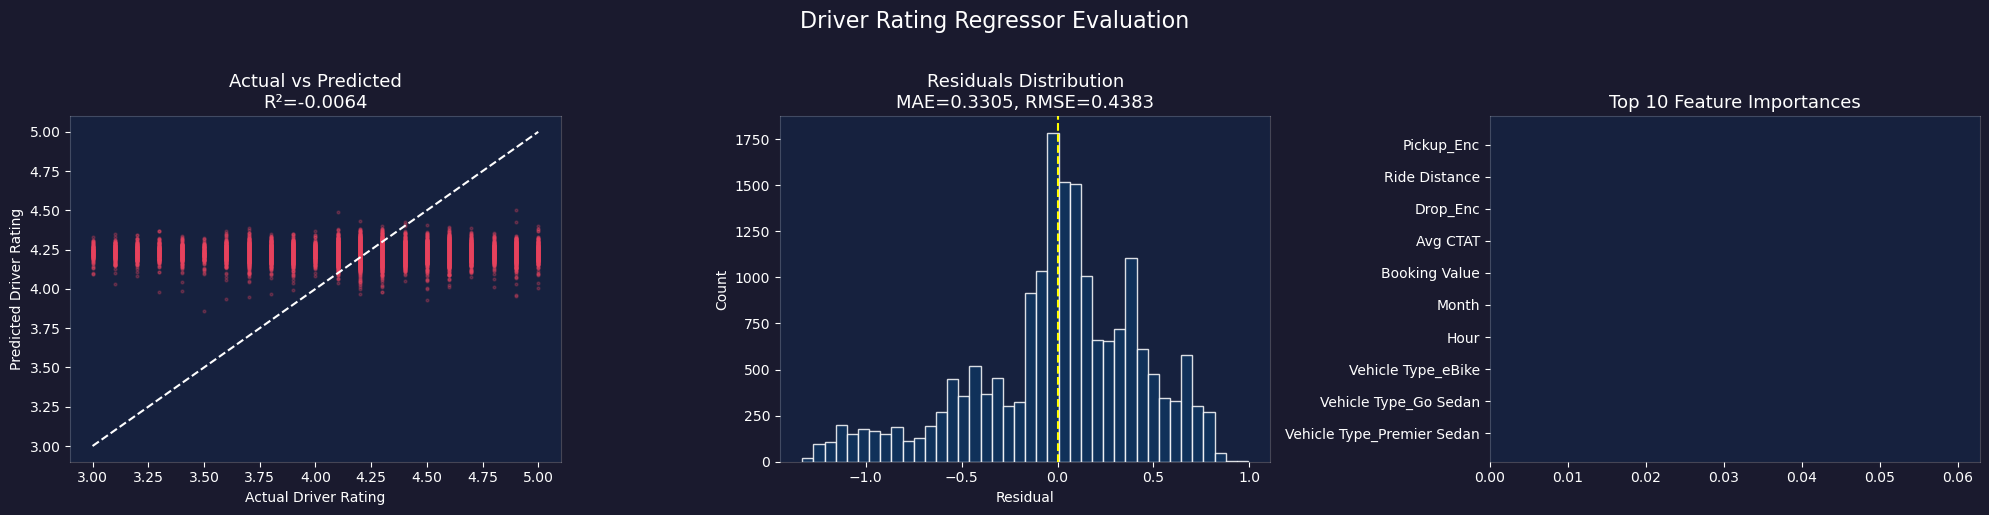

In [20]:
# ── 19. Visualise Driver Rating Predictions ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Actual vs Predicted
axes[0].scatter(y_test_dr, y_pred_dr, alpha=0.25, s=4, color=PALETTE[0], rasterized=True)
axes[0].plot([y_test_dr.min(), y_test_dr.max()],
             [y_test_dr.min(), y_test_dr.max()], 'w--', lw=1.5)
axes[0].set_xlabel("Actual Driver Rating"); axes[0].set_ylabel("Predicted Driver Rating")
axes[0].set_title(f"Actual vs Predicted\nR²={r2_dr:.4f}", fontsize=13)

# Residuals distribution
residuals = y_test_dr.values - y_pred_dr
axes[1].hist(residuals, bins=40, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='yellow', linestyle='--')
axes[1].set_title(f"Residuals Distribution\nMAE={mae_dr:.4f}, RMSE={rmse_dr:.4f}", fontsize=13)
axes[1].set_xlabel("Residual"); axes[1].set_ylabel("Count")

# Feature importances
ohe_feats_reg = preprocessor_reg.named_transformers_['ohe'].get_feature_names_out(CATEGORICAL_OHE).tolist()
all_feats_reg = NUMERICAL_FEATURES_ENC + ohe_feats_reg
fi_dr = pd.Series(xgb_dr_pipeline.named_steps['regressor'].feature_importances_,
                  index=all_feats_reg[:len(xgb_dr_pipeline.named_steps['regressor'].feature_importances_)]).nlargest(10)
axes[2].barh(fi_dr.index[::-1], fi_dr.values[::-1], color=PALETTE[2])
axes[2].set_title("Top 10 Feature Importances", fontsize=13)

plt.suptitle("Driver Rating Regressor Evaluation", fontsize=16, y=1.02)
plt.tight_layout(); plt.show()


In [21]:
# ── 20. Save Driver Rating Model ──────────────────────────────────────────
joblib.dump(xgb_dr_pipeline, f"{MODELS_DIR}/xgb_driver_rating_pipeline.pkl")
print("✅ Driver Rating model saved")


✅ Driver Rating model saved


## ⭐ Section 5 — Model 3: Customer Rating Regressor

In [22]:
# ── 21. Prepare Customer Rating Dataset ──────────────────────────────────
# Use same completed-rides dataframe
X_cr = reg_df[reg_features]
y_cr = reg_df['Customer Rating']

mask_cr  = y_cr.notna()
X_cr, y_cr = X_cr[mask_cr], y_cr[mask_cr]

X_train_cr, X_test_cr, y_train_cr, y_test_cr = train_test_split(
    X_cr, y_cr, test_size=0.2, random_state=42
)
print(f"Customer Rating dataset — Train: {X_train_cr.shape} | Test: {X_test_cr.shape}")

Customer Rating dataset — Train: (74400, 12) | Test: (18600, 12)


In [23]:
# ── 22. XGBoost Regressor — Customer Rating ──────────────────────────────
num_imp_cr = SimpleImputer(strategy='median')
ohe_cr     = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor_cr = ColumnTransformer(transformers=[
    ('num', num_imp_cr, NUMERICAL_FEATURES_ENC),
    ('ohe', ohe_cr,     CATEGORICAL_OHE),
], remainder='drop')

xgb_cr_pipeline = Pipeline([
    ('preprocessor', preprocessor_cr),
    ('regressor',    XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    ))
])

xgb_cr_pipeline.fit(X_train_cr, y_train_cr)
y_pred_cr = xgb_cr_pipeline.predict(X_test_cr)
y_pred_cr = np.clip(y_pred_cr, 1.0, 5.0)

mae_cr  = mean_absolute_error(y_test_cr, y_pred_cr)
rmse_cr = np.sqrt(mean_squared_error(y_test_cr, y_pred_cr))
r2_cr   = r2_score(y_test_cr, y_pred_cr)

print("=" * 50)
print("  CUSTOMER RATING REGRESSOR (XGBoost)")
print("=" * 50)
print(f"  MAE  : {mae_cr:.4f}")
print(f"  RMSE : {rmse_cr:.4f}")
print(f"  R²   : {r2_cr:.4f}")

  CUSTOMER RATING REGRESSOR (XGBoost)
  MAE  : 0.3489
  RMSE : 0.4420
  R²   : -0.0096


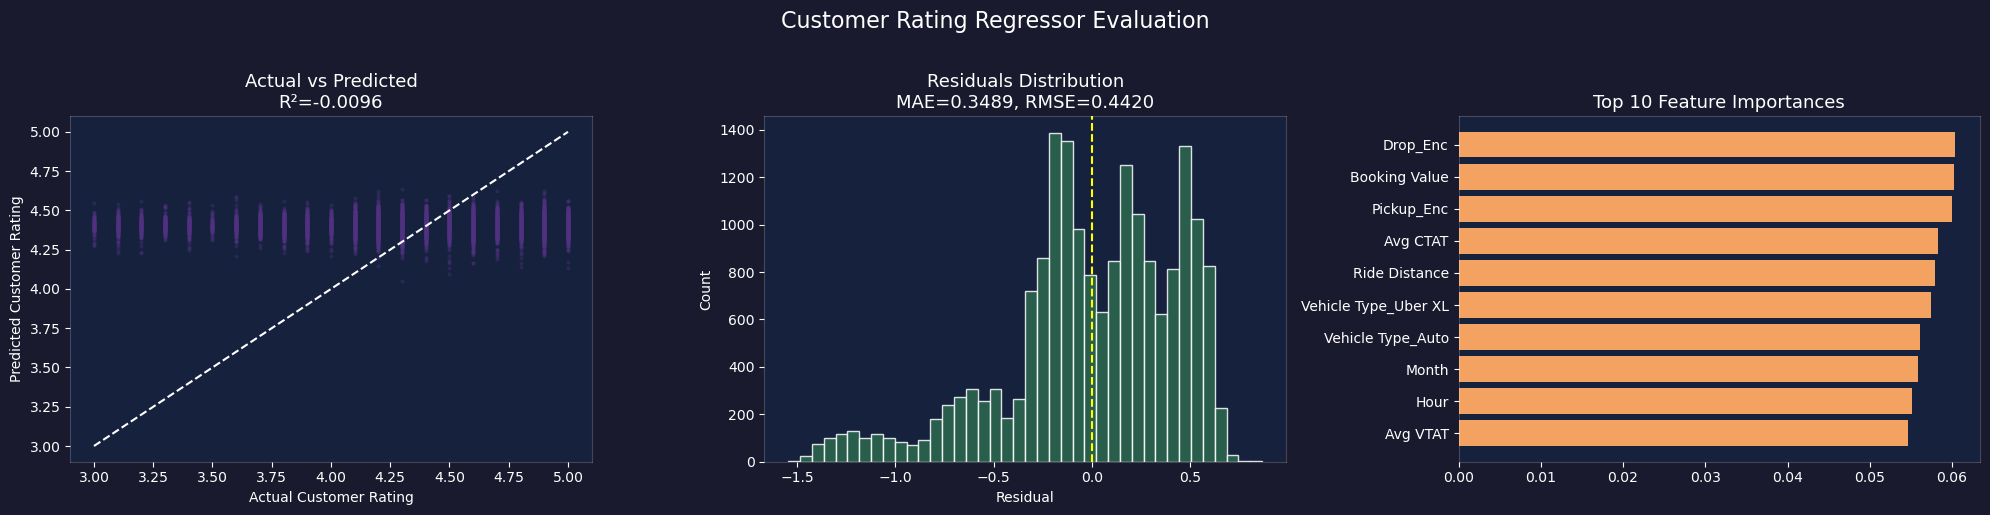

In [24]:
# ── 23. Visualise Customer Rating Predictions ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].scatter(y_test_cr, y_pred_cr, alpha=0.25, s=4, color=PALETTE[3], rasterized=True)
axes[0].plot([y_test_cr.min(), y_test_cr.max()],
             [y_test_cr.min(), y_test_cr.max()], 'w--', lw=1.5)
axes[0].set_xlabel("Actual Customer Rating"); axes[0].set_ylabel("Predicted Customer Rating")
axes[0].set_title(f"Actual vs Predicted\nR²={r2_cr:.4f}", fontsize=13)

residuals_cr = y_test_cr.values - y_pred_cr
axes[1].hist(residuals_cr, bins=40, color=PALETTE[4], edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='yellow', linestyle='--')
axes[1].set_title(f"Residuals Distribution\nMAE={mae_cr:.4f}, RMSE={rmse_cr:.4f}", fontsize=13)
axes[1].set_xlabel("Residual"); axes[1].set_ylabel("Count")

ohe_feats_cr = preprocessor_cr.named_transformers_['ohe'].get_feature_names_out(CATEGORICAL_OHE).tolist()
all_feats_cr = NUMERICAL_FEATURES_ENC + ohe_feats_cr
fi_cr = pd.Series(xgb_cr_pipeline.named_steps['regressor'].feature_importances_,
                  index=all_feats_cr[:len(xgb_cr_pipeline.named_steps['regressor'].feature_importances_)]).nlargest(10)
axes[2].barh(fi_cr.index[::-1], fi_cr.values[::-1], color=PALETTE[5])
axes[2].set_title("Top 10 Feature Importances", fontsize=13)

plt.suptitle("Customer Rating Regressor Evaluation", fontsize=16, y=1.02)
plt.tight_layout(); plt.show()


In [25]:
# ── 24. Save Customer Rating Model ───────────────────────────────────────
joblib.dump(xgb_cr_pipeline, f"{MODELS_DIR}/xgb_customer_rating_pipeline.pkl")

['saved_models/xgb_customer_rating_pipeline.pkl']

## 📋 Section 6 — Final Summary

In [26]:
# ── 25. Model Performance Summary ────────────────────────────────────────
from sklearn.metrics import roc_auc_score

print("\n" + "=" * 65)
print("  📊  NCR RIDE BOOKINGS — MODEL PERFORMANCE SUMMARY")
print("=" * 65)

print("\n  🟠 TARGET 1 : Ride Cancellation (Binary Classification)")
print("  ─" * 30)
print(f"  Random Forest  AUC-ROC : {roc_auc_score(y_test_c, y_proba_rf_c):.4f}")
print(f"  XGBoost        AUC-ROC : {roc_auc_score(y_test_c, y_proba_xgb_c):.4f}")

print("\n  🔵 TARGET 2 : Driver Rating (Regression)")
print("  ─" * 30)
print(f"  XGBoost  MAE={mae_dr:.4f}  RMSE={rmse_dr:.4f}  R²={r2_dr:.4f}")

print("\n  🟢 TARGET 3 : Customer Rating (Regression)")
print("  ─" * 30)
print(f"  XGBoost  MAE={mae_cr:.4f}  RMSE={rmse_cr:.4f}  R²={r2_cr:.4f}")

print("\n  💾 Saved Artifacts")
print("  ─" * 30)
import os
for f in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(f"{MODELS_DIR}/{f}") / 1e6
    print(f"  {f:<45} {size:.2f} MB")
print("=" * 65)


  📊  NCR RIDE BOOKINGS — MODEL PERFORMANCE SUMMARY

  🟠 TARGET 1 : Ride Cancellation (Binary Classification)
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
  Random Forest  AUC-ROC : 0.9931
  XGBoost        AUC-ROC : 0.9931

  🔵 TARGET 2 : Driver Rating (Regression)
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
  XGBoost  MAE=0.3305  RMSE=0.4383  R²=-0.0064

  🟢 TARGET 3 : Customer Rating (Regression)
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
  XGBoost  MAE=0.3489  RMSE=0.4420  R²=-0.0096

  💾 Saved Artifacts
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
  le_drop.pkl                                   0.00 MB
  le_pickup.pkl                                 0.00 MB
  preprocessor.pkl                              0.00 MB
  rf_cancellation_pipeline.pkl                  16.11 MB
  version_manifest.json       

In [27]:
# ── 26. Cross-Validation Summary (Regression) ────────────────────────────
print("Cross-Validation (5-fold) MAE Scores:")

# Driver Rating
cv_scores_dr = cross_val_score(
    xgb_dr_pipeline, X_dr, y_dr,
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)
print(f"  Driver Rating   — CV MAE: {-cv_scores_dr.mean():.4f} ± {cv_scores_dr.std():.4f}")

# Customer Rating
cv_scores_cr = cross_val_score(
    xgb_cr_pipeline, X_cr, y_cr,
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)
print(f"  Customer Rating — CV MAE: {-cv_scores_cr.mean():.4f} ± {cv_scores_cr.std():.4f}")
print("\n✅ All models trained, evaluated, and saved successfully!")


Cross-Validation (5-fold) MAE Scores:


TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.
